In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
import matplotlib.pyplot as plt
import torch
import math
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
df = pd.read_csv('Yemen_Rainfall_1982_2025.csv')
df

,Unnamed: 0,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version,month,dekad,year
0,454320,1982-01-01,2,32878,0,24.0,1.000000,1.043055,4.000000,3.880556,9.833333,14.137500,99.287520,101.34500,77.509250,final,1,1,1982
1,478770,1982-01-01,2,32893,1,19.0,1.157895,1.049123,4.157895,4.145614,9.263158,13.300000,101.798140,100.13426,77.940760,final,1,1,1982
2,455950,1982-01-01,2,32879,2,10.0,1.000000,1.023333,4.000000,4.253334,9.400000,12.836667,99.612610,97.26224,80.732574,final,1,1,1982
3,457580,1982-01-01,2,32880,3,9.0,1.000000,1.003704,4.000000,4.166666,9.888889,13.162963,99.938310,98.18182,81.973900,final,1,1,1982
4,464100,1982-01-01,2,32884,4,6.0,1.000000,1.055556,4.000000,4.094444,10.000000,13.688889,99.082570,98.96152,80.261600,final,1,1,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503707,277333,2025-12-21,2,145040,313,7.0,2.000000,1.652381,4.285714,4.523809,12.142858,17.409523,105.225480,97.50000,76.498085,final,12,21,2025
503708,273655,2025-12-21,2,145039,314,9.0,2.000000,1.600000,4.000000,4.322222,12.444444,17.692593,106.060616,96.54351,76.872850,final,12,21,2025
503709,292463,2025-12-21,2,999528,315,10.0,1.800000,1.570000,4.600000,4.146667,17.800000,21.576668,103.500770,104.95627,85.789530,final,12,21,2025
503710,228307,2025-12-21,2,145016,316,88.0,14.522727,14.787121,34.545456,41.764393,58.613636,74.689390,98.663810,84.56318,79.826980,final,12,21,2025


In [4]:
df.columns

Index(['Unnamed: 0', 'date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh',
       'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q',
       'version', 'month', 'dekad', 'year'],
      dtype='object')

In [5]:
df = df.drop(['rfq','r1q','r3q','rfh_avg','r1h_avg','r3h_avg','n_pixels','version','Unnamed: 0','adm_id', 'adm_level'], axis=1)
df = df.sort_values(by=['PCODE', 'year', 'month', 'dekad']).reset_index(drop=True)
df

,date,PCODE,rfh,r1h,r3h,month,dekad,year
0,1982-01-01,0,1.000000,4.000000,9.833333,1,1,1982
1,1982-01-11,0,3.000000,6.000000,12.000000,1,11,1982
2,1982-01-21,0,1.000000,5.000000,12.000000,1,21,1982
3,1982-02-01,0,1.000000,5.000000,12.000000,2,1,1982
4,1982-02-11,0,3.583333,5.583333,14.583333,2,11,1982
...,...,...,...,...,...,...,...,...
503707,2025-11-11,317,5.289473,10.289474,12.657895,11,11,2025
503708,2025-11-21,317,6.394737,15.473684,18.789474,11,21,2025
503709,2025-12-01,317,7.710527,19.394737,26.184212,12,1,2025
503710,2025-12-11,317,11.842105,25.947369,37.710526,12,11,2025


In [6]:
lags = [1, 2, 3, 6, 12]

def create_lags(df):
    df = df.sort_values(['PCODE','year','month','dekad'])
    
    for lag in [1,2,3,6,12]:
        df[f'rfh_lag_{lag}'] = df.groupby('PCODE')['rfh'].shift(lag)
    
    return df

df = create_lags(df)
df = df.dropna()

In [7]:
df['PCODE'] = df['PCODE'].astype('category').cat.codes

In [8]:
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

df['dekad_sin'] = np.sin(2*np.pi*df['dekad']/3)
df['dekad_cos'] = np.cos(2*np.pi*df['dekad']/3)

In [9]:
df.columns

Index(['date', 'PCODE', 'rfh', 'r1h', 'r3h', 'month', 'dekad', 'year',
       'rfh_lag_1', 'rfh_lag_2', 'rfh_lag_3', 'rfh_lag_6', 'rfh_lag_12',
       'month_sin', 'month_cos', 'dekad_sin', 'dekad_cos'],
      dtype='object')

In [10]:
final_features = [
    'rfh','r1h','r3h',
    'rfh_lag_1','rfh_lag_2','rfh_lag_3','rfh_lag_6','rfh_lag_12',
    'month_sin', 'month_cos', 'dekad_sin', 'dekad_cos',
    'month','dekad'
]
target = 'rfh'

In [11]:
df_log = df.copy()

cols = ['rfh', 'r1h', 'r3h']
for col in cols:
    df_log[col] = np.log1p(df_log[col])

In [12]:
train_df = df_log[df_log['date'] <= '2015-12-31']
val_df   = df_log[(df_log['date'] > '2015-12-31') & (df_log['date'] <= '2020-12-31')]
test_df  = df_log[df_log['date'] > '2020-12-31']

In [13]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df.loc[:, final_features] = x_scaler.fit_transform(train_df[final_features])
val_df.loc[:, final_features]   = x_scaler.transform(val_df[final_features])
test_df.loc[:, final_features]  = x_scaler.transform(test_df[final_features])

train_df.loc[:, target] = y_scaler.fit_transform(train_df[[target]])
val_df.loc[:, target]   = y_scaler.transform(val_df[[target]])
test_df.loc[:, target]  = y_scaler.transform(test_df[[target]])

In [14]:
def create_sequences_per_pcode(df, features, target, seq_len=24):
    X_list, y_list, pcode_list = [], [], []
    
    for pcode, group in df.groupby('PCODE'):
        group = group.sort_values(['year','month','dekad'])
        
        X = group[features].values
        y = group[target].values
        
        for i in range(len(group) - seq_len):
            X_list.append(X[i:i+seq_len])
            y_list.append(y[i+seq_len])
            pcode_list.append(pcode)
    
    return (
        torch.tensor(X_list, dtype=torch.float32),
        torch.tensor(y_list, dtype=torch.float32),
        torch.tensor(pcode_list, dtype=torch.long)
    )

In [15]:
X_train, y_train, p_train = create_sequences_per_pcode(train_df, final_features, target)
X_val, y_val, p_val       = create_sequences_per_pcode(val_df, final_features, target)
X_test, y_test, p_test    = create_sequences_per_pcode(test_df, final_features, target)

/tmp/ipykernel_9628/103391394.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(X_list, dtype=torch.float32),


In [16]:
X_train.shape # (batch_size, sequence_length, num_features)

torch.Size([377784, 24, 14])

In [17]:
train_ds = TensorDataset(X_train, y_train, p_train)
val_ds   = TensorDataset(X_val, y_val, p_val)
test_ds  = TensorDataset(X_test, y_test, p_test)

In [18]:
train_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

In [19]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, num_pcodes, embed_dim, d_model, n_heads, num_layers, dropout):
        super().__init__()
        
        self.embedding = nn.Embedding(num_pcodes, embed_dim)
        
        self.input_proj = nn.Linear(input_dim + embed_dim, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, pcode):
        emb = self.embedding(pcode)  # (batch, embed_dim)
        
        emb = emb.unsqueeze(1).repeat(1, x.size(1), 1)
        
        x = torch.cat([x, emb], dim=2)
        x = self.input_proj(x)
        x = self.transformer(x)
        
        x = x[:, -1, :]
        return self.fc(x)

In [20]:
import optuna

def objective(trial):
    try:
        torch.cuda.empty_cache()

        d_model = trial.suggest_categorical("d_model", [32, 64,128])
        n_heads = trial.suggest_categorical("n_heads", [2, 4])
        num_layers = trial.suggest_int("num_layers", 1, 2,3)
        dropout = trial.suggest_float("dropout", 0.2, 0.4)
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
        embed_dim = trial.suggest_categorical("embed_dim", [4, 8])

        model = TransformerModel(
            input_dim=X_train.shape[2],
            num_pcodes=df['PCODE'].nunique(),
            embed_dim=embed_dim,
            d_model=d_model,
            n_heads=n_heads,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        #  TRAIN
        for epoch in range(10):
            model.train()
            total_loss = 0

            for xb, yb, pb in train_loader:
                xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

                optimizer.zero_grad()
                pred = model(xb, pb)

                loss = loss_fn(pred.view(-1), yb.view(-1))
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

        #  VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for xb, yb, pb in val_loader:
                xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

                pred = model(xb, pb)
                loss = loss_fn(pred.view(-1), yb.view(-1))
                val_loss += loss.item()

        return val_loss / len(val_loader)

    except Exception as e:
        print("Trial failed:", e)
        return float("inf")

In [21]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20)  

[I 2026-04-12 11:25:39,710] A new study created in memory with name: no-name-574c62df-080d-463e-a2a6-deba5fa4cdc9
/tmp/ipykernel_9628/3490139413.py:9: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  num_layers = trial.suggest_int("num_layers", 1, 2,3)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/optuna/distributions.py:684: UserWarning: The distribution is specified by [1, 2] and step=3, but the range is not divisible by `step`. It will be replaced with [1, 1].
  optuna_warn(
[I 2026-04-12 11:28:36,952] Trial 0 finished with value: 0.016575677363566823 and parameters: {'d_model': 1

In [22]:
print("Best Trial Loss:", study.best_trial.value)

best = study.best_params

print("\nBest Params:")
for k, v in best.items():
    print(f"{k}: {v}")

Best Trial Loss: 0.011023137168766758

Best Params:
d_model: 32
n_heads: 2
num_layers: 1
dropout: 0.3359757139056996
lr: 0.0002057503037472738
embed_dim: 8


In [23]:
model = TransformerModel(
    input_dim=X_train.shape[2],
    num_pcodes=df['PCODE'].nunique(),
    embed_dim=best['embed_dim'],
    d_model=best['d_model'],
    n_heads=best['n_heads'],
    num_layers=best['num_layers'],
    dropout=best['dropout']
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best['lr'])
loss_fn = nn.MSELoss()

In [24]:
for epoch in range(50):
    model.train()
    total_loss = 0

    for xb, yb, pb in train_loader:
        xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

        optimizer.zero_grad()
        pred = model(xb, pb)

        loss = loss_fn(pred.view(-1), yb.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 0.0394
Epoch 2, Loss: 0.0201
Epoch 3, Loss: 0.0169
Epoch 4, Loss: 0.0143
Epoch 5, Loss: 0.0130
Epoch 6, Loss: 0.0124
Epoch 7, Loss: 0.0114
Epoch 8, Loss: 0.0100
Epoch 9, Loss: 0.0093
Epoch 10, Loss: 0.0088
Epoch 11, Loss: 0.0085
Epoch 12, Loss: 0.0082
Epoch 13, Loss: 0.0080
Epoch 14, Loss: 0.0078
Epoch 15, Loss: 0.0076
Epoch 16, Loss: 0.0075
Epoch 17, Loss: 0.0074
Epoch 18, Loss: 0.0073
Epoch 19, Loss: 0.0072
Epoch 20, Loss: 0.0071
Epoch 21, Loss: 0.0070
Epoch 22, Loss: 0.0069
Epoch 23, Loss: 0.0068
Epoch 24, Loss: 0.0068
Epoch 25, Loss: 0.0067
Epoch 26, Loss: 0.0067
Epoch 27, Loss: 0.0066
Epoch 28, Loss: 0.0065
Epoch 29, Loss: 0.0065
Epoch 30, Loss: 0.0065
Epoch 31, Loss: 0.0065
Epoch 32, Loss: 0.0064
Epoch 33, Loss: 0.0064
Epoch 34, Loss: 0.0064
Epoch 35, Loss: 0.0063
Epoch 36, Loss: 0.0063
Epoch 37, Loss: 0.0062
Epoch 38, Loss: 0.0062
Epoch 39, Loss: 0.0061
Epoch 40, Loss: 0.0061
Epoch 41, Loss: 0.0061
Epoch 42, Loss: 0.0060
Epoch 43, Loss: 0.0060
Epoch 44, Loss: 0.00

In [25]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb, pb in val_loader:
        xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

        pred = model(xb, pb)

        all_preds.extend(pred.view(-1).cpu().numpy())
        all_targets.extend(yb.view(-1).cpu().numpy())

In [ ]:
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae  = mean_absolute_error(all_targets, all_preds)
r2   = r2_score(all_targets, all_preds)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 0.09241434
MAE : 0.06752396
R2  : 0.7251315478532385


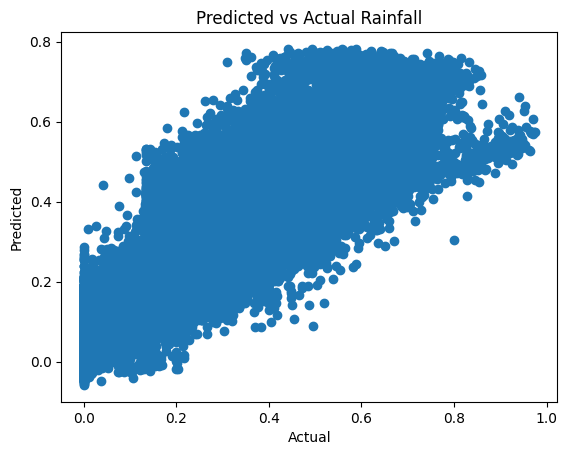

In [27]:
plt.figure()
plt.scatter(all_targets, all_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Rainfall")
plt.show()

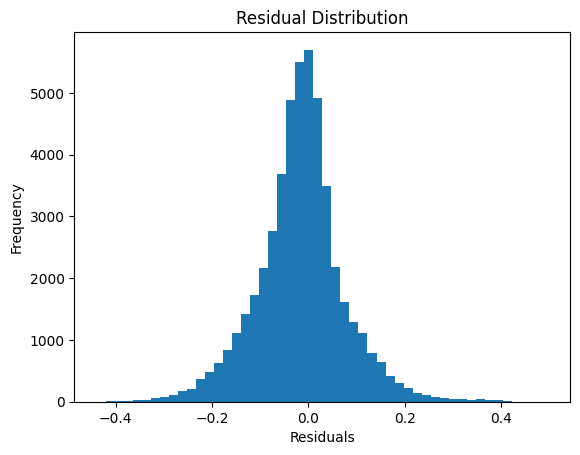

In [28]:
residuals = np.array(all_targets) - np.array(all_preds)

plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

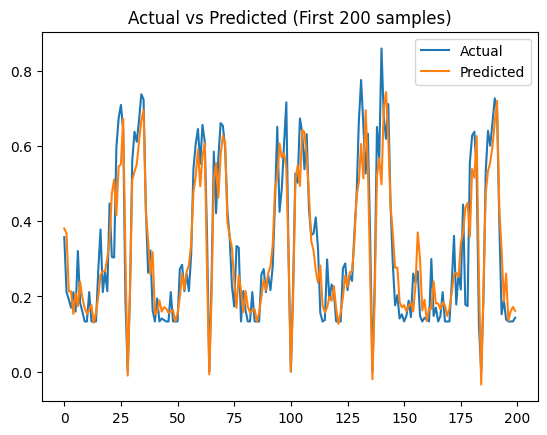

In [29]:
plt.figure()
plt.plot(all_targets[:200], label="Actual")
plt.plot(all_preds[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 200 samples)")
plt.show()

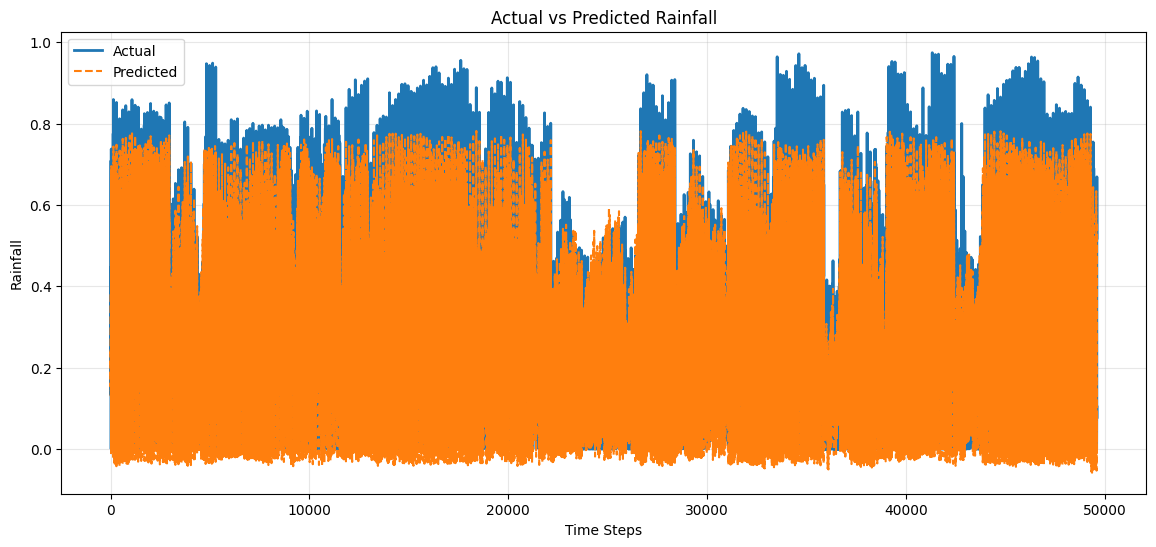

In [30]:
y_true = np.array(all_targets).flatten()
y_pred = np.array(all_preds).flatten()

plt.figure(figsize=(14,6))

plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle='--')

plt.title("Actual vs Predicted Rainfall")
plt.xlabel("Time Steps")
plt.ylabel("Rainfall")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

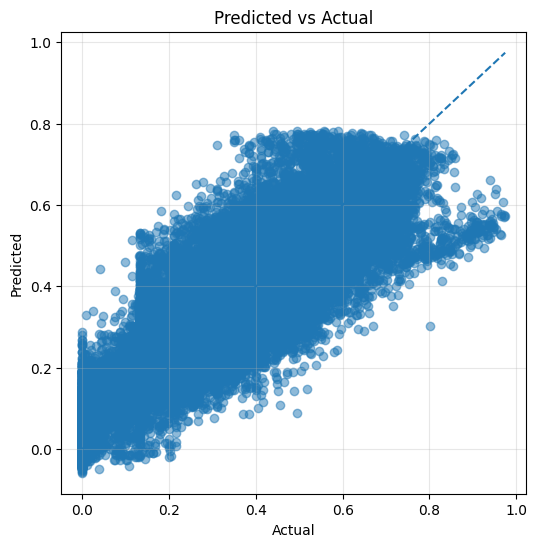

In [31]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

# perfect prediction line
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

plt.grid(alpha=0.3)

# lt.savefig("scatter_plot_lstm.png", dpi=300)
plt.show()

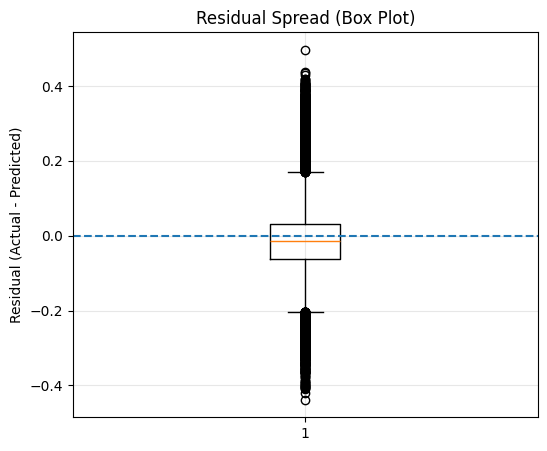

In [32]:
y_true = np.array(all_targets).flatten()
y_pred = np.array(all_preds).flatten()

# Residuals
residuals = y_true - y_pred

plt.figure(figsize=(6,5))

plt.boxplot(residuals, vert=True)

# zero reference line
plt.axhline(0, linestyle='--')

plt.title("Residual Spread (Box Plot)")
plt.ylabel("Residual (Actual - Predicted)")

plt.grid(alpha=0.3)

plt.savefig("residual_boxplot.png", dpi=300)
plt.show()

In [33]:
results = pd.DataFrame({
    "actual": all_targets,
    "pred": all_preds
})

results.to_csv("encoder_transformer_results.csv", index=False)